In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

PROJECT_DIR = Path(
    r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1"
)

CATALOG = PROJECT_DIR / "data" / "dmdg_catalog_z0.csv"

df = pd.read_csv(CATALOG)

print(f"Number of subhalos: {len(df):,}")
print(df["f_DM"].describe())

Number of subhalos: 13,922,457
count    1.238633e+06
mean     8.730135e-01
std      1.821868e-01
min      0.000000e+00
25%      8.523382e-01
50%      9.241443e-01
75%      9.691053e-01
max      9.997234e-01
Name: f_DM, dtype: float64


Create and access catalog

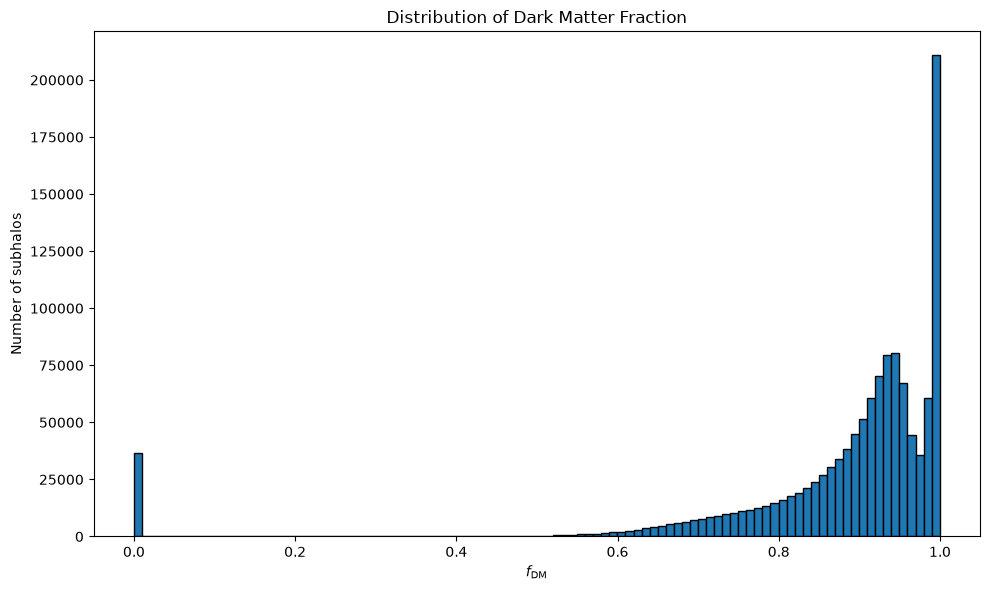

In [6]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["f_DM"].dropna(),
    bins=100,
    edgecolor="black"
)

plt.xlabel(r"$f_{\rm DM}$")
plt.ylabel("Number of subhalos")
plt.title("Distribution of Dark Matter Fraction")

plt.tight_layout()
plt.show()

Make plot

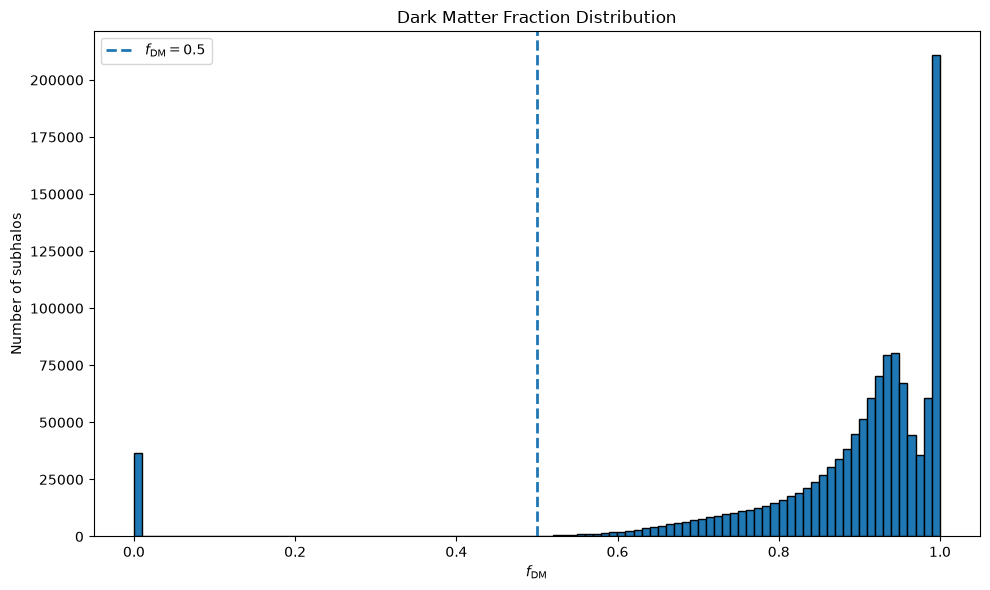

In [7]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["f_DM"].dropna(),
    bins=100,
    edgecolor="black"
)

plt.axvline(
    0.5,
    linestyle="--",
    linewidth=2,
    label=r"$f_{\rm DM}=0.5$"
)

plt.xlabel(r"$f_{\rm DM}$")
plt.ylabel("Number of subhalos")
plt.title("Dark Matter Fraction Distribution")

plt.legend()

plt.tight_layout()
plt.show()

Fractional cutoff


In [8]:
valid = df["f_DM"].notna()

n_total = valid.sum()

n_dmdg = (
    (df["f_DM"] < 0.5)
    & valid
).sum()

fraction = n_dmdg / n_total

print(f"Valid subhalos: {n_total:,}")
print(f"f_DM < 0.5: {n_dmdg:,}")
print(f"Fraction: {fraction:.6%}")

Valid subhalos: 1,238,633
f_DM < 0.5: 41,918
Fraction: 3.384215%


In [9]:
dmdg = df[df["f_DM"] < 0.5].copy()

print("DMDG candidates:", len(dmdg))

print("\nStellar mass:")
print(dmdg["M_star"].describe())

print("\nStar particle count:")
print(dmdg["N_star"].describe())

print("\nHost mass:")
print(dmdg["Host_M200c"].describe())

print("\nCentral/satellite:")
print(dmdg["IsSatellite"].value_counts())

print("\nSubhaloFlag:")
print(dmdg["SubhaloFlag"].value_counts())

print("\nDark matter mass inside 2Rh:")
print(dmdg["M_DM_2Rh"].describe())

print("\nTotal mass inside 2Rh:")
print(dmdg["M_total_2Rh"].describe())

DMDG candidates: 41918

Stellar mass:
count    41918.000000
mean         0.133114
std          0.603402
min          0.000649
25%          0.006241
50%          0.021850
75%          0.071836
max         31.312744
Name: M_star, dtype: float64

Star particle count:
count    41918.000000
mean       262.434491
std       1191.916250
min          2.000000
25%         10.000000
50%         41.000000
75%        143.000000
max      60941.000000
Name: N_star, dtype: float64

Host mass:
count     41918.000000
mean       3128.994869
std        8893.724816
min           0.011309
25%          98.679310
50%         378.101000
75%        2112.316200
max      104034.410000
Name: Host_M200c, dtype: float64

Central/satellite:
IsSatellite
True     41572
False      346
Name: count, dtype: int64

SubhaloFlag:
SubhaloFlag
False    34337
True      7581
Name: count, dtype: int64

Dark matter mass inside 2Rh:
count    41918.000000
mean         0.056387
std          0.392831
min          0.000000
25%          

In [10]:
print("\nHow many have essentially zero DM?")
print((dmdg["M_DM_2Rh"] == 0).sum())

print("\nHow many have zero stars?")
print((dmdg["M_star"] == 0).sum())

print("\nHow many have zero star particles?")
print((dmdg["N_star"] == 0).sum())

print("\nHow many are flagged non-cosmological?")
print((dmdg["SubhaloFlag"] == 0).sum())


How many have essentially zero DM?
36355

How many have zero stars?
0

How many have zero star particles?
0

How many are flagged non-cosmological?
34337


In [11]:
plt.figure(figsize=(10,6))

plt.hist(
    dmdg["M_star"].replace(0, np.nan).dropna(),
    bins=100
)

plt.xscale("log")
plt.xlabel(r"$M_\star\ [M_\odot]$")
plt.ylabel("Number of objects")
plt.title(r"Stellar Mass of $f_{\rm DM}<0.5$ Candidates")

plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

<Figure size 1000x600 with 0 Axes>